In [2]:
import ctypes
import numpy as np
import os
import matplotlib.pyplot as plt

# Charger la DLL
lib = ctypes.CDLL("../library/ML/ML_dll.dll")

# Définir la structure LinearModel en Python
class LinearModel(ctypes.Structure):
    _fields_ = [("weights", ctypes.POINTER(ctypes.c_double)),
                ("bias", ctypes.POINTER(ctypes.c_double)),
                ("loss", ctypes.POINTER(ctypes.c_double)),
                ("loss_size", ctypes.c_size_t)]

# Définir les types de retour et les arguments des fonctions
lib.train_linear_model.restype = LinearModel
lib.train_linear_model.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
                                   ctypes.c_size_t, ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t,
                                   ctypes.c_size_t, ctypes.c_bool]

lib.predict_linear_model.restype = ctypes.POINTER(ctypes.c_double)
lib.predict_linear_model.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
                                     ctypes.POINTER(ctypes.c_double), ctypes.c_size_t, ctypes.c_size_t,
                                     ctypes.c_size_t, ctypes.c_bool]

# Fonction pour tracer les frontières de décision
def plot_decision_boundary(model, X, y, ax, is_classification):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.zeros(grid.shape[0])

    for i, (gx, gy) in enumerate(grid):
        sample = np.array([gx, gy], dtype=np.float64)
        sample_ctypes = sample.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
        prediction_ctypes = lib.predict_linear_model(sample_ctypes, model.weights, model.bias, 1, 2, 1, is_classification)
        zz[i] = prediction_ctypes[0]

    zz = zz.reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-1, 0, 1], alpha=0.3, cmap='coolwarm')
    y_colors = y.flatten()
    ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.coolwarm)


Weights: [1.0, -4.899669313789716e-15]
Bias: [-0.9999999999999885]
Loss values: [0.5, 0.02842897563052106, 0.028418685099879087, 0.028418673243929885, 0.02841867323722513, 0.028418673237222192, 0.028418673237222324, 0.028418673237222324, 0.028418673237222244, 0.028418673237222192, 0.028418673237222376]


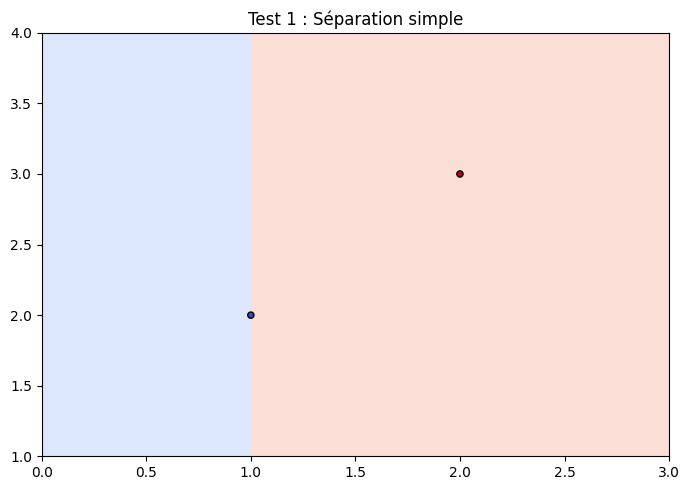

In [3]:
num_samples = 2
num_features = 2
k = 1
learning_rate = 0.01
num_iterations = 100000
is_classification = True

X = np.array([[1, 2], [2, 3]], dtype=np.float64)
Y = np.array([0, 1], dtype=np.float64).reshape(-1, 1)

features_ctypes = X.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
outputs_ctypes = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# Appeler la fonction d'entraînement
model = lib.train_linear_model(features_ctypes, outputs_ctypes, num_samples, num_features,
                               learning_rate, num_iterations, k, is_classification)

# Afficher les résultats
weights = [model.weights[i] for i in range(num_features * k)]
bias = [model.bias[i] for i in range(k)]
loss_values = [model.loss[i] for i in range(model.loss_size)]

print("Weights:", weights)
print("Bias:", bias)
print("Loss values:", loss_values)

# Tracer la frontière de décision
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(model, X, Y, ax, is_classification)
ax.set_title('Test 1 : Séparation simple')
plt.tight_layout()
plt.show()


Weights: [-0.8788746329942037, -0.8710360048498839]
Bias: [3.3757965407229]
Loss values: [0.960603150131822, 0.12386462774175372]


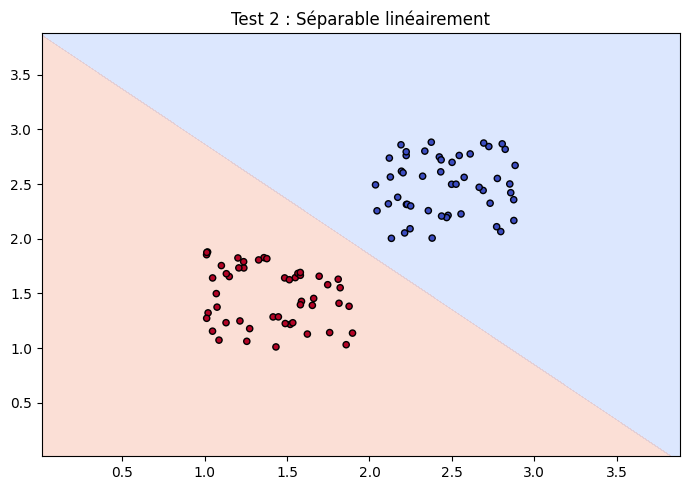

In [4]:
num_samples = 100
num_features = 2
k = 1
learning_rate = 0.01
num_iterations = 10000
is_classification = True

X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]), np.random.random((50, 2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0]).astype(np.float64)

features_ctypes = X.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
outputs_ctypes = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# Appeler la fonction d'entraînement
model = lib.train_linear_model(features_ctypes, outputs_ctypes, num_samples, num_features,
                               learning_rate, num_iterations, k, is_classification)

# Afficher les résultats
weights = [model.weights[i] for i in range(num_features * k)]
bias = [model.bias[i] for i in range(k)]
loss_values = [model.loss[i] for i in range(model.loss_size)]

print("Weights:", weights)
print("Bias:", bias)
print("Loss values:", loss_values)

# Tracer la frontière de décision
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(model, X, Y, ax, is_classification)
ax.set_title('Test 2 : Séparable linéairement')
plt.tight_layout()
plt.show()


Weights: [0.5999999999999999, 0.0, -0.3999999999999998, 0.20000000000000004]
Bias: [0.20000000000000004]
Loss values: [0.5]


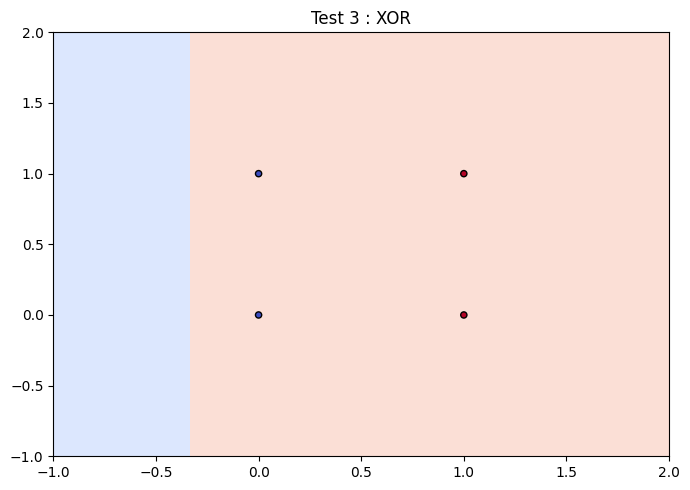

In [5]:
num_samples = 2
num_features = 4
k = 1
learning_rate = 0.1
num_iterations = 1000
is_classification = True

X = np.array([[0, 0], [1, 1], [1, 0], [0, 1]], dtype=np.float64)
Y = np.array([0, 1, 1, 0], dtype=np.float64).reshape(-1, 1)

features_ctypes = X.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
outputs_ctypes = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# Appeler la fonction d'entraînement
model = lib.train_linear_model(features_ctypes, outputs_ctypes, num_samples, num_features,
                               learning_rate, num_iterations, k, is_classification)

# Afficher les résultats
weights = [model.weights[i] for i in range(num_features * k)]
bias = [model.bias[i] for i in range(k)]
loss_values = [model.loss[i] for i in range(model.loss_size)]

print("Weights:", weights)
print("Bias:", bias)
print("Loss values:", loss_values)

# Tracer la frontière de décision
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(model, X, Y, ax, is_classification)
ax.set_title('Test 3 : XOR')
plt.tight_layout()
plt.show()


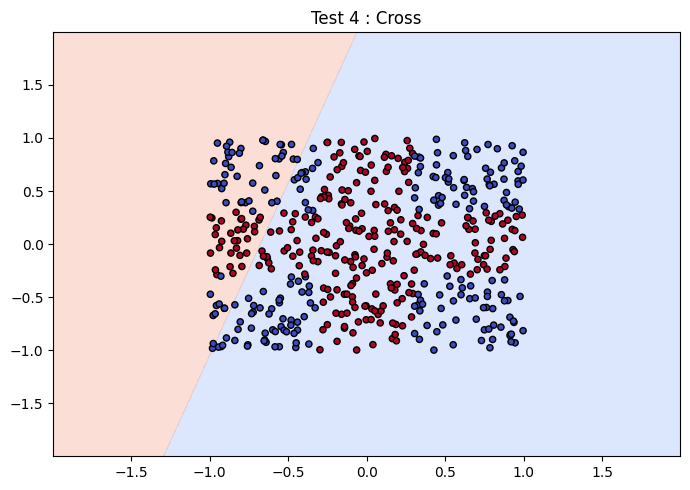

In [6]:
def run_test_cross():
    # Définir les données d'entraînement pour le cas de test "Cross"
    X = np.random.random((500, 2)) * 2.0 - 1.0
    Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X]).reshape(-1, 1)

    # Paramètres d'apprentissage
    learning_rate = 0.01
    num_iterations = 10000

    # Convertir les données en ctypes
    features_ctypes = X.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    outputs_ctypes = Y.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    # Entraîner le modèle
    model = lib.train_linear_model(features_ctypes, outputs_ctypes, len(X), X.shape[1], learning_rate, num_iterations, 1, True)

    # Tracer la frontière de décision
    fig, ax = plt.subplots(figsize=(7, 5))


    plot_decision_boundary(model, X, Y, ax, True)
    ax.set_title('Test 4 : Cross')

    plt.tight_layout()
    plt.show()

run_test_cross()


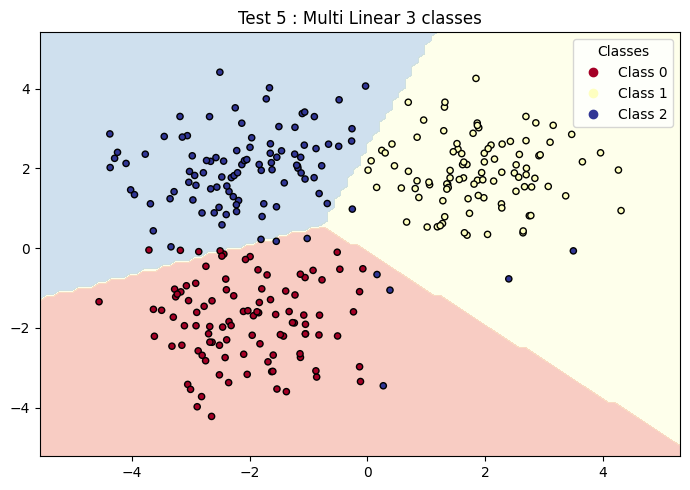

In [13]:
def run_test_5():
    num_samples = 300
    np.random.seed(0)
    X = np.concatenate([np.random.randn(100, 2) + np.array([-2, -2]), 
                        np.random.randn(100, 2) + np.array([2, 2]),
                        np.random.randn(100, 2) + np.array([-2, 2])])
    Y = np.array([[1, 0, 0] if p[0] < 0 and p[1] < 0 else
                  [0, 1, 0] if p[0] > 0 and p[1] > 0 else
                  [0, 0, 1] for p in X])

    learning_rate = 0.01
    num_iterations = 100000

    features_ctypes = X.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    outputs_ctypes = Y.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    model = lib.train_linear_model(features_ctypes, outputs_ctypes, len(X), X.shape[1], learning_rate, num_iterations, 3, True)

    fig, ax = plt.subplots(figsize=(7, 5))

    # Function to plot decision boundary for three classes
    def plot_decision_boundary_3class(model, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros((grid.shape[0], 3))

        for i, (gx, gy) in enumerate(grid):
            sample = np.array([gx, gy], dtype=np.float64)
            sample_ctypes = sample.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
            prediction_ctypes = lib.predict_linear_model(sample_ctypes, model.weights, model.bias, 1, 2, 3, is_classification)
            zz[i] = np.ctypeslib.as_array(prediction_ctypes, shape=(3,))

        zz = np.argmax(zz, axis=1).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=np.arange(4) - 0.5, alpha=0.3, cmap=plt.cm.RdYlBu)

        y_colors = np.argmax(y, axis=1)
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        handles, labels = scatter.legend_elements(prop="colors")
        labels = ["Class 0", "Class 1", "Class 2"]
        ax.legend(handles, labels, loc="upper right", title="Classes")

    plot_decision_boundary_3class(model, X, Y, ax, True)
    ax.set_title('Test 5 : Multi Linear 3 classes')

    plt.tight_layout()
    plt.show()

run_test_5()


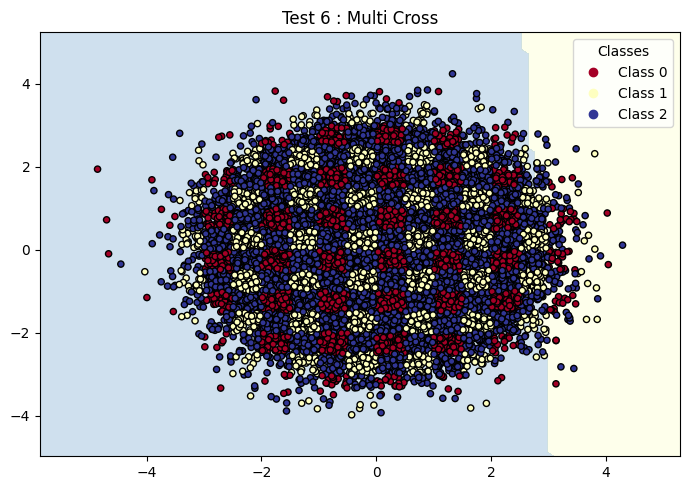

In [8]:
def run_test_6():
    num_samples = 100000
    np.random.seed(0)
    X = np.random.randn(num_samples, 2)
    Y = np.array([[1, 0, 0] if abs(p[0] % 1) <= 0.5 and abs(p[1] % 1) > 0.5 else 
                  [0, 1, 0] if abs(p[0] % 1) > 0.5 and abs(p[1] % 1) <= 0.5 else 
                  [0, 0, 1] for p in X])

    learning_rate = 0.01
    num_iterations = 10000

    features_ctypes = X.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    outputs_ctypes = Y.flatten().astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    model = lib.train_linear_model(features_ctypes, outputs_ctypes, len(X), X.shape[1], learning_rate, num_iterations, 3, True)

    fig, ax = plt.subplots(figsize=(7, 5))

    def plot_decision_boundary_3class(model, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros((grid.shape[0], 3))

        for i, (gx, gy) in enumerate(grid):
            sample = np.array([gx, gy], dtype=np.float64)
            sample_ctypes = sample.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
            prediction_ctypes = lib.predict_linear_model(sample_ctypes, model.weights, model.bias, 1, 2, 3, is_classification)
            zz[i] = np.ctypeslib.as_array(prediction_ctypes, shape=(3,))

        zz = np.argmax(zz, axis=1).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=np.arange(4) - 0.5, alpha=0.3, cmap=plt.cm.RdYlBu)

        y_colors = np.argmax(y, axis=1)
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        handles, labels = scatter.legend_elements(prop="colors")
        labels = ["Class 0", "Class 1", "Class 2"]
        ax.legend(handles, labels, loc="upper right", title="Classes")

    plot_decision_boundary_3class(model, X, Y, ax, True)
    ax.set_title('Test 6 : Multi Cross')

    plt.tight_layout()
    plt.show()

run_test_6()
